The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


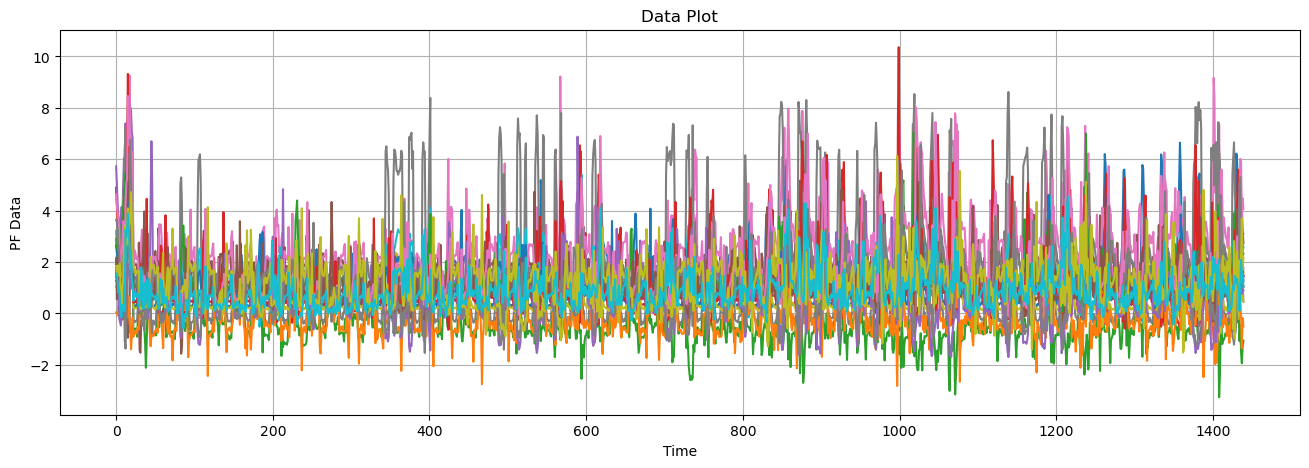

In [90]:
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
import numpy as np
import networkx as nx
import lib.plotGraph as plotGraph
import lib.ioFile as ioFile
import lib.powerfun as powerfun
import lib.graph as graph
import lib.threshold as threshold
import lib.residual as resd
import lib.subBase as subBase
import lib.utils as utils
import lib.ac_se_fdia as ac_se_fdia
from skimage.filters import threshold_li
import pandas as pd
import lib.cycle_space as csp
import tqdm
from scipy.stats import chi2
from lib.read_ac_pf_csv import read_ac_power_flow_data
from scipy.linalg import qr
import pandapower as pp
import pandapower.networks as nw
import numpy as np
from sklearn.preprocessing import StandardScaler
from scipy.linalg import null_space
import warnings

mode= "DC" # DC
powerID= 14
IEEENames= ["IEEE 14", "IEEE 30", "IEEE 57", "IEEE 118"]
case_map = {14: nw.case14, 30: nw.case30, 57: nw.case57, 118: nw.case118}
net = case_map[powerID]()
outPutFile= False
# Load MATLAB file
matpower_file= f'matpower/test_data/{mode}_case{powerID}_.mat' #14, 118, 57, 30
DC_file= f'data/paper_2/results{powerID}.xlsx' # DC
#
_, _, H, A, _, resistance, _, reactance= ioFile.read_mat_power(matpower_file, normalize= False)
pfData, _=ioFile.read_excel_power(DC_file, id1= 0, id2= 0)
#
noZeroBranches= np.nonzero(np.abs(H).sum(axis= 0)!=0)
H= H[:, noZeroBranches].squeeze()
A= A[:, noZeroBranches].squeeze()
param= np.sum(np.abs(H), axis= 1, keepdims= True)/2
m= H.shape[0]
n= H.shape[1]
rankH= n-1
nullity= m- rankH
stdOfNoise= 2e-2
numTrain= m+1
#

phaseData= (np.linalg.pinv(H)@pfData.T).T
normalPfData= H.dot(phaseData.T).T
noiseVector= np.random.randn(pfData.shape[0], pfData.shape[1])
noiseE= noiseVector*stdOfNoise
noisePfData= pfData.copy()+noiseE
trainDataNp= noisePfData[:numTrain, :]
testDataNp= noisePfData[numTrain:, :]

plotTimeSeries= True
if plotTimeSeries:
    plt.figure(figsize=(16, 5))
    for i in range(m):
        plt.plot(pfData[:, i], label=i)
    # plt.yscale("log")
    plt.title('Data Plot')
    plt.xlabel('Time')
    plt.ylabel('PF Data')
    plt.grid(True)
    plt.show()

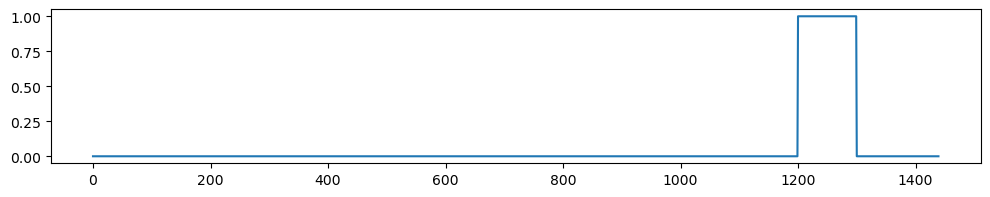

In [91]:
attackPeriod= np.linalg.norm((normalPfData-pfData)[:, ], axis= 1)>1e-8
plt.figure(figsize=(12, 2)) 
plt.plot(attackPeriod) 
linkRemove= 0 #0 or 9
# A[linkRemove, :]= 0 # Comment out to 
G, node_pair2id = graph.from_A_to_G(A)
minimum_cycle_b= nx.minimum_cycle_basis(G, weight="weight")
minimum_cycle_b= [list(i) for i in minimum_cycle_b]
minimum_cycle_e= []
for nodeCycle in minimum_cycle_b:
    S = G.subgraph(list(nodeCycle))
    linkCycle= [node_pair2id[(nodeCycle[i-1], nodeCycle[i])] for i in range(len(nodeCycle))]
    minimum_cycle_e.append(set(linkCycle))
_, cSpaceClean, _= resd.cycle_residual(pfData[:numTrain, :], rankH, m, pfData[numTrain:, :], minimum_cycle_e)
NcSpaceClean= cSpaceClean@np.linalg.pinv(cSpaceClean.T@cSpaceClean)@cSpaceClean.T

num links
20


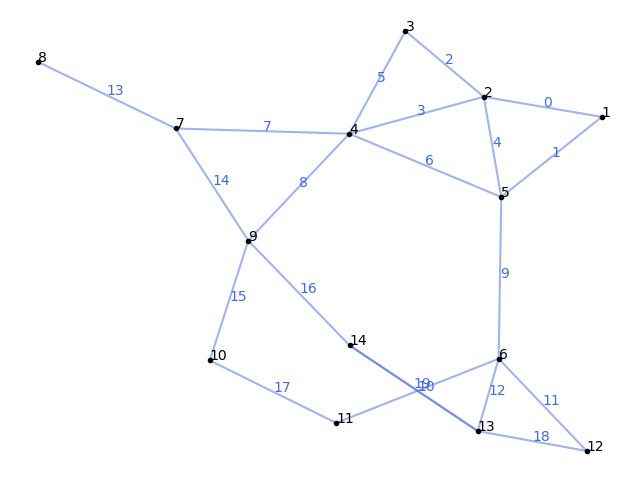

In [92]:
print("num links")
print(G.number_of_edges())
biconnected_components = list(nx.biconnected_components(G))
largest_bcc = list(max(biconnected_components, key=len))
plotGraph.plot_spring_layout(G, label= True, label_edge= True, node_pair2id= node_pair2id)

In [93]:
U, S, V= np.linalg.svd(H)
uAttack= np.ones((H.shape[0], 1))
uAttack= uAttack/np.linalg.norm(uAttack)
sAttack= (H@V[rankH-1, :])[:, None]
sAttack= sAttack/np.linalg.norm(sAttack)
print(uAttack.T@sAttack)
print(sAttack.T)
print(sAttack.shape)
print(np.abs(uAttack.T@U[:, 0:rankH-1]))
print(np.square(np.linalg.norm(uAttack.T@U[:, 0:rankH-1])))
print(np.square(np.linalg.norm(uAttack.T@U[:, rankH-1:])))
# print(S)


[[-0.65313359]]
[[-0.03230099 -0.13058167  0.02004093 -0.1516578  -0.15650844 -0.17954632
  -0.01124158 -0.44342093 -0.21131992 -0.65660945  0.04104055 -0.16941426
  -0.18498569 -0.00733139 -0.22546793 -0.10195315 -0.25861291 -0.16474295
   0.09625663  0.00745507]]
(20, 1)
[[0.2233461  0.12041524 0.04284361 0.31106881 0.27225878 0.2356042
  0.06621761 0.18596594 0.24208399 0.05609552 0.13436862 0.24314424]]
0.47051039211438733
0.5294896078856124


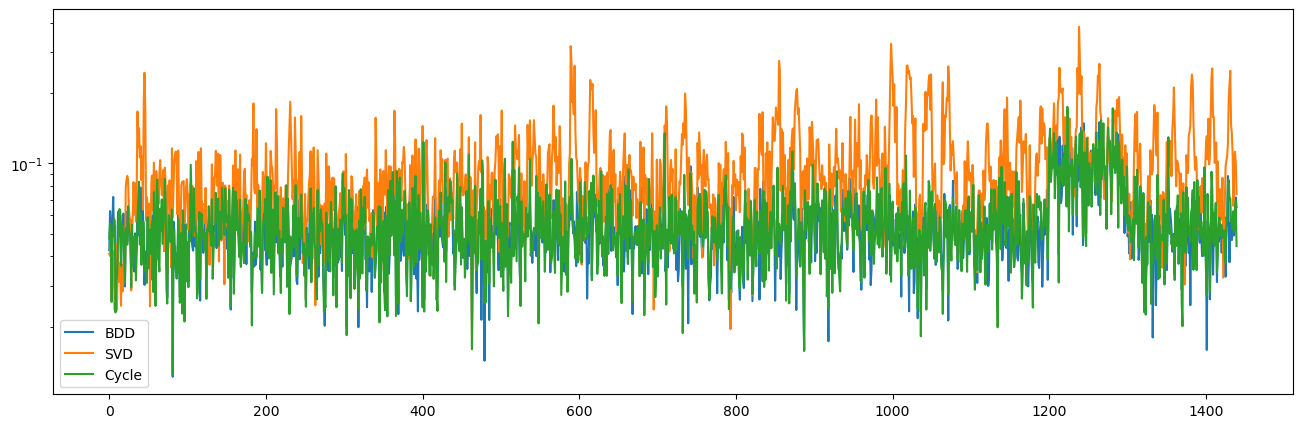

In [8]:
trainPfTmp= noisePfData[:numTrain, :] 
U, S, V= np.linalg.svd(trainPfTmp.T@trainPfTmp)
nullSpace= V[-nullity:, :]
detect2= nullSpace@noisePfData.T
U, S, V= np.linalg.svd(H@H.T)
nullSpaceH= V[-nullity:, :]
detect1= nullSpaceH@noisePfData.T
errorC, cSpace, wholeRight = resd.cycle_residual(trainPfTmp, rankH, m, noisePfData, minimum_cycle_e)
normDetect1= np.linalg.norm(detect1.T, axis= 1)
normDetect2= np.linalg.norm(detect2.T, axis= 1)
normDetect3= np.linalg.norm(errorC, axis= 0)
plt.figure(figsize=(16, 5))
plt.plot(normDetect1, label= "BDD")
plt.plot(normDetect2, label= "SVD")
plt.plot(normDetect3, label= "Cycle")
plt.legend()
plt.yscale("log")

In [9]:
import json
data_to_save = {
    "BDD": normDetect1.tolist(),
    "SVD": normDetect2.tolist(),
    "Cycle": normDetect3.tolist()
}
with open(f'data/results_dc2/IEEE{powerID}.json', 'w') as f:
    json.dump(data_to_save, f, indent=4)

In [36]:
from sklearn.metrics import precision_recall_curve, auc

mapPrecisionC= np.zeros((m-n+1, 100, 100))
mapPrecisionAll= np.zeros((1, 100, 100))
mapRecallC= np.zeros((m-n+1, 100, 100))
mapRecallAll= np.zeros((1, 100, 100))
mapPrecisionSVD= np.zeros((1, 100, 100))
mapPrecisionBDD= np.zeros((1, 100, 100))
mapRecallSVD= np.zeros((1, 100, 100))
mapRecallBDD= np.zeros((1, 100, 100))

originStdMeasurement= np.std((normalPfData-pfData))
LenofOriginAttack= np.sqrt(np.square(originStdMeasurement)*H.shape[0])
ratio= 0.1/LenofOriginAttack/100
ratio2= np.sqrt(0.0245/H.shape[0])
x_axis_label= []
lossCycle= []
lossSVD= []
confidence_level= 0.99
for i in tqdm.tqdm(range(100)):
    scale= (i)*ratio
    newAttackPfData= (normalPfData-pfData)*scale+normalPfData
    stdOfMeasurement= np.std((normalPfData-newAttackPfData))
    lenMeasurement= np.sqrt(np.square(stdOfMeasurement)*H.shape[0])
    x_axis_label.append(str(np.round(lenMeasurement, 3)))
    y_axis_label= []
    for j in range(100):
        noiseStd= ratio2*((j)/100)**3
        lenNoise= np.sqrt(np.square(noiseStd)*H.shape[0])
        y_axis_label.append(str(np.round(lenNoise, 3)))
        tmpMeasurement= (newAttackPfData+noiseVector*noiseStd)
        trainPfTmp= tmpMeasurement[:numTrain, :] 
        errorC, cSpace, wholeRight = resd.cycle_residual(trainPfTmp, rankH, m, tmpMeasurement, minimum_cycle_e)
        residualC= np.linalg.norm(errorC, axis= 0)
        if i==0:
            NcSpace= cSpace@np.linalg.inv(cSpace.T@cSpace)@cSpace.T
            lossCycle.append(np.linalg.norm(NcSpace- NcSpaceClean))
        precision, recall, _, _= threshold.li_threshold(residualC, attackPeriod)
        mapPrecisionAll[0, j, i]= precision
        mapRecallAll[0, j, i]= recall
        for k in range(len(minimum_cycle_e)):
            precision, recall, _, _= threshold.li_threshold(errorC[k, :], attackPeriod)
            mapPrecisionC[k, j, i]= precision
            mapRecallC[k, j, i]= recall
        U, S, V= np.linalg.svd(trainPfTmp.T@trainPfTmp)
        nullSpace= V[-nullity:, :]
        detect2= nullSpace@tmpMeasurement.T
        U, S, V= np.linalg.svd(H@H.T)
        nullSpaceH= V[-nullity:, :]
        detect1= nullSpaceH@tmpMeasurement.T
        normDetect1= np.linalg.norm(detect1.T, axis= 1)
        precision, recall, _, _= threshold.li_threshold(normDetect1, attackPeriod)
        mapPrecisionBDD[0, j, i]= precision
        mapRecallBDD[0, j, i]= recall
        normDetect2= np.linalg.norm(detect2.T, axis= 1)
        precision, recall, _, _= threshold.li_threshold(normDetect2, attackPeriod)
        mapPrecisionSVD[0, j, i]= precision
        mapRecallSVD[0, j, i]= recall


100%|██████████| 100/100 [00:26<00:00,  3.78it/s]


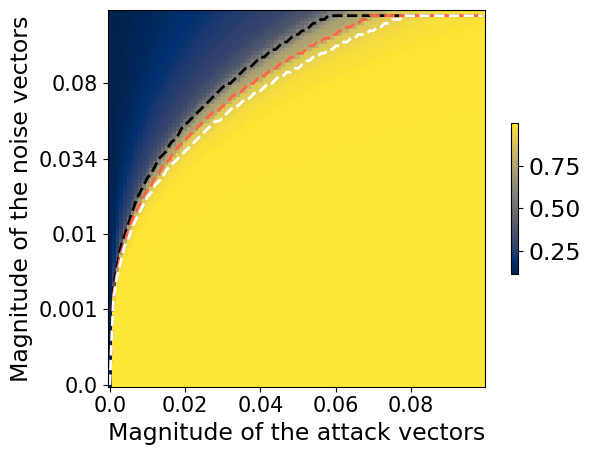

In [38]:
from matplotlib.colors import Normalize
plt.figure()
loadPrevious= False
fontsize= 17 #1 or 15
if loadPrevious:
    powerID= 30
    mapPrecisionC= np.load(f'log/{powerID}_mapPrecisionC.npy')
    mapRecallC= np.load(f'log/{powerID}_mapRecallC.npy')
    mapPrecisionAll= np.load(f'log/{powerID}_mapPrecisionAll.npy')
    mapRecallAll= np.load(f'log/{powerID}_mapRecallAll.npy')
np.save(f'log/{powerID}_mapPrecisionC.npy', mapPrecisionC)
np.save(f'log/{powerID}_mapRecallC.npy', mapRecallC)
np.save(f'log/{powerID}_mapPrecisionAll.npy', mapPrecisionAll)
np.save(f'log/{powerID}_mapRecallAll.npy', mapRecallAll)

f1C= 2*mapPrecisionC*mapRecallC/(mapRecallC+mapPrecisionC+1e-5)
f1All= 2*mapPrecisionAll*mapRecallAll/(mapRecallAll+mapPrecisionAll+1e-5)
f1SVD= 2*mapPrecisionSVD*mapRecallSVD/(mapRecallSVD+mapPrecisionSVD+1e-5)
f1BDD= 2*mapPrecisionBDD*mapRecallBDD/(mapRecallBDD+mapPrecisionBDD+1e-5)

heatToShow= f1All[0, :, :]# mapImpact, f1
plotHere= plt.imshow(heatToShow, cmap=  "cividis", norm=Normalize(vmin=np.min(heatToShow), vmax= np.max(heatToShow)), origin='lower')
f1Csum= (f1C[:, ...]>0.8).sum(axis= 1)
f1Allsum= (f1All[0, ...]>0.8).sum(axis= 0)
f1SVDsum= (f1SVD[0, ...]>0.8).sum(axis= 0)
f1BDDsum= (f1BDD[0, ...]>0.8).sum(axis= 0)
f1Csum[f1Csum>98.5]= 98
f1Allsum[f1Allsum>98.5]= 98
f1SVDsum[f1SVDsum>98.5]= 98
f1BDDsum[f1BDDsum>98.5]= 98
# plt.plot(f1BDDsum.T, linestyle='dashed',  color= "green", linewidth=2)
# plt.plot(f1SVDsum.T, linestyle='dashed',  color= "purple", linewidth=2)
# plt.plot(f1Csum.T, linestyle='dashed',  color= "royalblue", linewidth=2)
plt.plot(f1AllsumCp, linestyle='dashed', color= "black", linewidth=2)
plt.plot(f1Allsum, linestyle='dashed', color= "tomato", linewidth=2)
plt.plot(f1AllsumCp2, linestyle='dashed', color= "white", linewidth=2)
colorbar =plt.colorbar(label= "", shrink=0.4) #State deviation
colorbar.ax.tick_params(labelsize= fontsize)
plt.xticks(ticks= [i*20 for i in range(5)], labels= [x_axis_label[i*20] for i in range(5)])
plt.yticks(ticks= [i*20 for i in range(5)], labels= [y_axis_label[i*20] for i in range(5)])
plt.rcParams.update({'font.size': 15})# 15 or 1
plt.ylabel("Magnitude of the noise vectors", fontsize= fontsize)
plt.xlabel("Magnitude of the attack vectors", fontsize= fontsize)
plt.tight_layout()
plt.show()

In [ ]:
# f1AllsumCp= f1Allsum.copy()
# f1AllsumCp2= f1Allsum.copy()